# 07 — Topology Comparison: $\mathbb{R}^2$ vs $S^1 \times \mathbb{R}$

When does the planar approximation break down and the cylindrical topology produce qualitatively different dynamics?

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from steering.params import ModelParams, ForcingParams
from steering.models import (
    DuffingModel,
    BesselSteeringModel,
    ContinuousPFLModel,
    DiscretePFLModel,
    FullCircuitModel,
)
from steering.dynamics import VelocityDynamics, AccelerationDynamics
from steering.integrator import Simulation
from steering.visualization.style import use_paper_style

use_paper_style()


In [2]:
bessel = BesselSteeringModel()
p = ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.4)


## Trajectory comparison

Strongly bistable + strong forcing → trajectory may wander to neighbouring wells via the $\theta = \pi$ saddle on $S^1$. Inside the Duffing-valid region the two topologies agree.

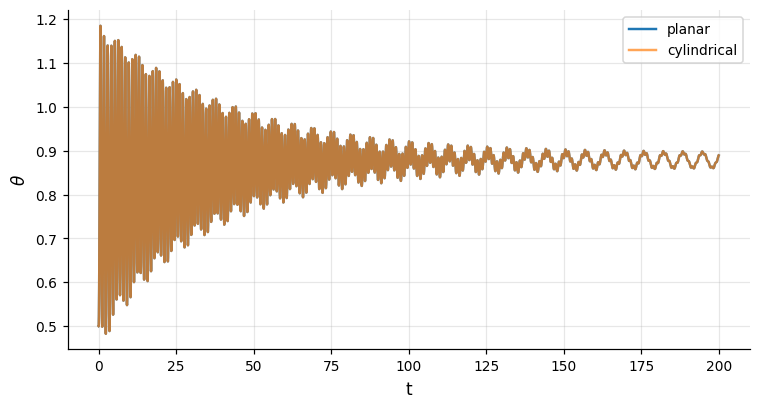

In [3]:
forc = ForcingParams(F=0.6, omega=1.0)
dyn_planar = AccelerationDynamics(model=bessel, gamma=0.05, topology='planar')
dyn_cylin = AccelerationDynamics(model=bessel, gamma=0.05, topology='cylindrical')
sim_p = Simulation(dyn_planar, p, forc, rtol=1e-9, atol=1e-11)
sim_c = Simulation(dyn_cylin, p, forc, rtol=1e-9, atol=1e-11)
r_p = sim_p.run(np.array([0.5, 0.0]), (0.0, 200.0))
r_c = sim_c.run(np.array([0.5, 0.0]), (0.0, 200.0))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_p.t, r_p.states[:, 0], label='planar')
ax.plot(r_c.t, r_c.states[:, 0], label='cylindrical', alpha=0.7)
ax.set_xlabel('t'); ax.set_ylabel(r'$\theta$'); ax.legend()
plt.show()


## Winding number on $S^1$

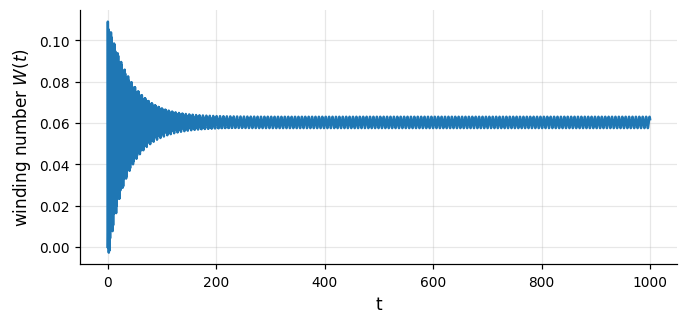

In [4]:
# Run on cylindrical topology but accumulate the *unwrapped* theta
# by integrating planar; then compute (unwrapped(t) - unwrapped(0))/(2pi).
r_long = sim_p.run(np.array([0.5, 0.0]), (0.0, 1000.0))
theta_unw = r_long.states[:, 0]
W_t = (theta_unw - theta_unw[0]) / (2.0*np.pi)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(r_long.t, W_t)
ax.set_xlabel('t'); ax.set_ylabel('winding number $W(t)$')
plt.show()
